# Grounding DINO Auto-Label Pipeline

This notebook is fully self-contained and Kaggle-ready. It:
- extracts frames from videos,
- filters irrelevant scenes,
- keeps rider-on-motorbike frames,
- detects no-helmet rider violations,
- exports COCO bbox annotations.

In [1]:
import subprocess
import sys

packages = [
    "torch",
    "torchvision",
    "transformers",
    "opencv-python-headless",
    "numpy",
    "Pillow",
    "matplotlib",
    "tqdm",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])
print("Dependencies installed.")

Dependencies installed.


## 0. Global Setup

Define environment-aware paths, logging, and class categories shared by all later stages.

In [2]:
from __future__ import annotations

import logging
from pathlib import Path

import torch

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("grounding_dino_pipeline")

IN_KAGGLE = Path("/kaggle").exists()
DEFAULT_VIDEO_GLOB = "/kaggle/input/datasets/dtdat1234/traffic-in-vietnam/video_scraping/*.mp4" if IN_KAGGLE else "data/raw/video_scraping/*.mp4"
DEFAULT_OUTPUT_ROOT = "/kaggle/working/grounding_dino_no_helmet" if IN_KAGGLE else "data/processed/grounding_dino_no_helmet"

COCO_CATEGORIES = [
    {"id": 1, "name": "motorcycle"},
    {"id": 2, "name": "person"},
    {"id": 3, "name": "helmet"},
    {"id": 4, "name": "no_helmet_rider"},
]
CATEGORY_TO_ID = {c["name"]: c["id"] for c in COCO_CATEGORIES}

print(f"IN_KAGGLE = {IN_KAGGLE}")
print(f"DEFAULT_VIDEO_GLOB = {DEFAULT_VIDEO_GLOB}")
print(f"DEFAULT_OUTPUT_ROOT = {DEFAULT_OUTPUT_ROOT}")
print(f"DEVICE = {'cuda' if torch.cuda.is_available() else 'cpu'}")

IN_KAGGLE = True
DEFAULT_VIDEO_GLOB = /kaggle/input/datasets/dtdat1234/traffic-in-vietnam/video_scraping/*.mp4
DEFAULT_OUTPUT_ROOT = /kaggle/working/grounding_dino_no_helmet
DEVICE = cuda


## 1. Data Models and Runtime Configuration

This section defines imports, dataclasses, and threshold/config options used by the rest of the pipeline.

In [3]:
import csv
import glob
import json
import math
import re
from dataclasses import dataclass, field
from datetime import datetime

import cv2
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
from transformers import AutoModelForZeroShotObjectDetection, AutoProcessor

@dataclass
class RunConfig:
    video_glob: str = DEFAULT_VIDEO_GLOB
    explicit_videos: list[str] = field(default_factory=list)
    output_root: str = DEFAULT_OUTPUT_ROOT

    sample_fps: float = 1.0
    max_frames_per_video: int | None = None

    model_id: str = "IDEA-Research/grounding-dino-tiny"
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    box_threshold: float = 0.35
    text_threshold: float = 0.25
    nms_iou_threshold: float = 0.50

    duplicate_hamming_threshold: int = 6

    rider_person_min_aspect_ratio: float = 1.05
    rider_person_min_area_ratio: float = 0.0015
    rider_iou_threshold: float = 0.02
    rider_motorcycle_expand: float = 1.30
    rider_center_distance_ratio: float = 1.45
    rider_score_threshold: float = 1.55

    head_region_ratio: float = 0.35
    helmet_head_iou_threshold: float = 0.02

    save_debug_images: bool = True

@dataclass
class Detection:
    label: str
    score: float
    box: tuple[float, float, float, float]
    raw_label: str

@dataclass
class FrameAnalysis:
    rider_motorcycles: list[Detection]
    rider_persons: list[Detection]
    rider_helmets: list[Detection]
    no_helmet_riders: list[Detection]

15:39:42  INFO      NumExpr defaulting to 4 threads.


## 2. Utility Functions

These helpers cover text normalization, geometry operations, hashing-based dedup, and class-wise NMS.

In [4]:
def sanitize_label(text: str) -> str:
    text = re.sub(r"[^a-z ]", " ", text.lower())
    return re.sub(r"\s+", " ", text).strip()


def canonicalize_label(raw_label: str) -> str | None:
    label = sanitize_label(raw_label)
    if "helmet" in label:
        return "helmet"
    if any(k in label for k in ("motorcycle", "motorbike", "scooter", "moped", "bike")):
        return "motorcycle"
    if any(k in label for k in ("person", "rider", "man", "woman", "people")):
        return "person"
    return None


def clip_box(
    box: tuple[float, float, float, float],
    width: int,
    height: int,
 ) -> tuple[float, float, float, float]:
    x1, y1, x2, y2 = box
    x1 = max(0.0, min(float(width - 1), x1))
    y1 = max(0.0, min(float(height - 1), y1))
    x2 = max(0.0, min(float(width - 1), x2))
    y2 = max(0.0, min(float(height - 1), y2))
    if x2 < x1:
        x1, x2 = x2, x1
    if y2 < y1:
        y1, y2 = y2, y1
    return (x1, y1, x2, y2)


def box_area(box: tuple[float, float, float, float]) -> float:
    x1, y1, x2, y2 = box
    return max(0.0, x2 - x1) * max(0.0, y2 - y1)


def iou(
    box_a: tuple[float, float, float, float],
    box_b: tuple[float, float, float, float],
 ) -> float:
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)
    inter = box_area((ix1, iy1, ix2, iy2))
    if inter <= 0:
        return 0.0
    union = box_area(box_a) + box_area(box_b) - inter
    return inter / union if union > 0 else 0.0


def expand_box(
    box: tuple[float, float, float, float],
    ratio: float,
    width: int,
    height: int,
 ) -> tuple[float, float, float, float]:
    x1, y1, x2, y2 = box
    cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0
    w = (x2 - x1) * ratio
    h = (y2 - y1) * ratio
    return clip_box((cx - w / 2.0, cy - h / 2.0, cx + w / 2.0, cy + h / 2.0), width, height)


def point_in_box(point: tuple[float, float], box: tuple[float, float, float, float]) -> bool:
    x, y = point
    x1, y1, x2, y2 = box
    return x1 <= x <= x2 and y1 <= y <= y2


def box_center(box: tuple[float, float, float, float]) -> tuple[float, float]:
    x1, y1, x2, y2 = box
    return ((x1 + x2) / 2.0, (y1 + y2) / 2.0)


def aspect_ratio(box: tuple[float, float, float, float]) -> float:
    x1, y1, x2, y2 = box
    w = max(1e-6, x2 - x1)
    h = max(1e-6, y2 - y1)
    return h / w


def box_to_xywh(box: tuple[float, float, float, float]) -> list[float]:
    x1, y1, x2, y2 = box
    return [round(x1, 2), round(y1, 2), round(max(0.0, x2 - x1), 2), round(max(0.0, y2 - y1), 2)]


def average_hash(frame_bgr: np.ndarray, hash_size: int = 8) -> np.ndarray:
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    small = cv2.resize(gray, (hash_size, hash_size), interpolation=cv2.INTER_AREA)
    return (small > small.mean()).astype(np.uint8)


def hamming_distance(hash_a: np.ndarray, hash_b: np.ndarray) -> int:
    return int(np.count_nonzero(hash_a != hash_b))


def nms_classwise(detections: list[Detection], iou_threshold: float) -> list[Detection]:
    by_class: dict[str, list[Detection]] = {}
    for det in detections:
        by_class.setdefault(det.label, []).append(det)

    kept: list[Detection] = []
    for class_dets in by_class.values():
        class_dets = sorted(class_dets, key=lambda d: d.score, reverse=True)
        class_kept: list[Detection] = []
        for cand in class_dets:
            if all(iou(cand.box, ex.box) < iou_threshold for ex in class_kept):
                class_kept.append(cand)
        kept.extend(class_kept)

    return kept

## 3. Grounding DINO Inference Wrapper

A thin wrapper around the Hugging Face Grounding DINO model for zero-shot detection.

In [5]:
class GroundingDinoDetector:
    def __init__(self, config: RunConfig) -> None:
        self.config = config
        self.prompt = "person . motorcycle . motorbike . scooter . helmet ."

        log.info("Loading model: %s", config.model_id)
        self.processor = AutoProcessor.from_pretrained(config.model_id)
        self.model = AutoModelForZeroShotObjectDetection.from_pretrained(config.model_id).to(config.device)
        self.model.eval()
        log.info("Loaded Grounding DINO on %s", config.device)

    @torch.inference_mode()
    def detect(self, image_pil: Image.Image) -> list[Detection]:
        inputs = self.processor(
            images=image_pil,
            text=self.prompt,
            return_tensors="pt",
        ).to(self.config.device)
        outputs = self.model(**inputs)

        target_sizes = [(image_pil.height, image_pil.width)]

        # Transformers versions differ in post-process argument names and signatures.
        try:
            processed = self.processor.post_process_grounded_object_detection(
                outputs,
                inputs.input_ids,
                box_threshold=self.config.box_threshold,
                text_threshold=self.config.text_threshold,
                target_sizes=target_sizes,
            )
        except TypeError:
            try:
                processed = self.processor.post_process_grounded_object_detection(
                    outputs,
                    inputs.input_ids,
                    threshold=self.config.box_threshold,
                    text_threshold=self.config.text_threshold,
                    target_sizes=target_sizes,
                )
            except TypeError:
                try:
                    processed = self.processor.post_process_grounded_object_detection(
                        outputs,
                        inputs.input_ids,
                        threshold=self.config.box_threshold,
                        target_sizes=target_sizes,
                    )
                except TypeError:
                    try:
                        processed = self.processor.post_process_grounded_object_detection(
                            outputs,
                            inputs.input_ids,
                            target_sizes=target_sizes,
                        )
                    except TypeError:
                        processed = self.processor.post_process_grounded_object_detection(
                            outputs,
                            target_sizes=target_sizes,
                        )

        results = processed[0]

        detections: list[Detection] = []
        for box, score, raw_label in zip(results["boxes"], results["scores"], results["labels"]):
            raw_label = str(raw_label)
            canonical = canonicalize_label(raw_label)
            if canonical is None:
                continue

            clipped = clip_box(
                tuple(float(v) for v in box.tolist()),
                image_pil.width,
                image_pil.height,
            )
            if box_area(clipped) <= 1.0:
                continue

            detections.append(Detection(canonical, float(score), clipped, raw_label))

        return nms_classwise(detections, self.config.nms_iou_threshold)

## 4. Rider and No-Helmet Reasoning

These heuristics reject irrelevant scenes and keep only probable rider cases.
Then rider head regions are matched with helmet detections to infer no-helmet violations.

In [6]:
def association_score(
    person_box: tuple[float, float, float, float],
    moto_box: tuple[float, float, float, float],
    image_w: int,
    image_h: int,
    config: RunConfig,
 ) -> float:
    score = 0.0

    ov = iou(person_box, moto_box)
    if ov >= config.rider_iou_threshold:
        score += 1.0 + min(0.5, ov)

    px1, py1, px2, py2 = person_box
    p_bottom_center = ((px1 + px2) / 2.0, py2)
    expanded_moto = expand_box(moto_box, config.rider_motorcycle_expand, image_w, image_h)
    if point_in_box(p_bottom_center, expanded_moto):
        score += 1.2

    p_center = box_center(person_box)
    m_center = box_center(moto_box)
    dist = math.dist(p_center, m_center)
    mx1, my1, mx2, my2 = moto_box
    m_diag = math.hypot(mx2 - mx1, my2 - my1)
    if m_diag > 1e-6:
        norm_dist = dist / m_diag
        if norm_dist <= config.rider_center_distance_ratio:
            score += max(0.0, 1.0 - norm_dist / config.rider_center_distance_ratio)

    if py2 < my1:
        score -= 0.5

    return score


def select_riders(
    persons: list[Detection],
    motorcycles: list[Detection],
    image_w: int,
    image_h: int,
    config: RunConfig,
 ) -> tuple[list[int], list[int]]:
    rider_person_idx: set[int] = set()
    rider_motor_idx: set[int] = set()
    min_person_area = config.rider_person_min_area_ratio * image_w * image_h

    for p_idx, person in enumerate(persons):
        if aspect_ratio(person.box) < config.rider_person_min_aspect_ratio:
            continue
        if box_area(person.box) < min_person_area:
            continue

        best_m_idx = -1
        best_score = 0.0
        for m_idx, moto in enumerate(motorcycles):
            score = association_score(person.box, moto.box, image_w, image_h, config)
            if score > best_score:
                best_score = score
                best_m_idx = m_idx

        if best_m_idx >= 0 and best_score >= config.rider_score_threshold:
            rider_person_idx.add(p_idx)
            rider_motor_idx.add(best_m_idx)

    return sorted(rider_person_idx), sorted(rider_motor_idx)


def head_region(person_box: tuple[float, float, float, float], ratio: float) -> tuple[float, float, float, float]:
    x1, y1, x2, y2 = person_box
    y2_head = y1 + max(2.0, ratio * max(1.0, y2 - y1))
    return (x1, y1, x2, min(y2, y2_head))


def match_helmets(
    rider_persons: list[Detection],
    helmets: list[Detection],
    config: RunConfig,
 ) -> tuple[list[int], list[int]]:
    riders_with_helmet: list[int] = []
    matched_helmet_idx: set[int] = set()

    for r_idx, rider in enumerate(rider_persons):
        head = head_region(rider.box, config.head_region_ratio)
        wearing = False

        for h_idx, helmet in enumerate(helmets):
            hx1, hy1, hx2, hy2 = helmet.box
            helmet_center = ((hx1 + hx2) / 2.0, (hy1 + hy2) / 2.0)
            ov = iou(head, helmet.box)
            if ov >= config.helmet_head_iou_threshold or point_in_box(helmet_center, head):
                wearing = True
                matched_helmet_idx.add(h_idx)

        if wearing:
            riders_with_helmet.append(r_idx)

    return riders_with_helmet, sorted(matched_helmet_idx)


def analyze_frame(
    frame_bgr: np.ndarray,
    detector: GroundingDinoDetector,
    config: RunConfig,
 ) -> FrameAnalysis | None:
    image_pil = Image.fromarray(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    detections = detector.detect(image_pil)

    motorcycles = [d for d in detections if d.label == "motorcycle"]
    persons = [d for d in detections if d.label == "person"]
    helmets = [d for d in detections if d.label == "helmet"]

    if not motorcycles or not persons:
        return None

    h, w = frame_bgr.shape[:2]
    rider_person_idx, rider_motor_idx = select_riders(persons, motorcycles, w, h, config)
    if not rider_person_idx or not rider_motor_idx:
        return None

    rider_persons = [persons[i] for i in rider_person_idx]
    rider_motorcycles = [motorcycles[i] for i in rider_motor_idx]

    riders_with_helmet_idx, matched_helmet_idx = match_helmets(rider_persons, helmets, config)
    rider_helmets = [helmets[i] for i in matched_helmet_idx]

    no_helmet_riders = [
        rider_persons[i]
        for i in range(len(rider_persons))
        if i not in riders_with_helmet_idx
    ]

    if not no_helmet_riders:
        return None

    return FrameAnalysis(
        rider_motorcycles=rider_motorcycles,
        rider_persons=rider_persons,
        rider_helmets=rider_helmets,
        no_helmet_riders=no_helmet_riders,
    )

## 5. Frame IO and COCO Helpers

This stage handles frame sampling, input video discovery, annotation builders, and debug visualization export.

In [7]:
def iter_sampled_frames(video_path: Path, sample_fps: float, max_frames_per_video: int | None):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        log.warning("Cannot open video: %s", video_path)
        return

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 25.0

    step = max(1, int(round(fps / max(0.1, sample_fps))))
    sampled = 0
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % step == 0:
            timestamp_s = frame_idx / fps
            yield frame_idx, timestamp_s, frame
            sampled += 1
            if max_frames_per_video is not None and sampled >= max_frames_per_video:
                break

        frame_idx += 1

    cap.release()


def resolve_video_paths(config: RunConfig) -> list[Path]:
    paths: list[Path] = []
    if config.video_glob:
        paths.extend(Path(p) for p in glob.glob(config.video_glob, recursive=True))
    paths.extend(Path(p) for p in config.explicit_videos)

    unique: list[Path] = []
    seen: set[str] = set()
    for p in paths:
        key = str(p.resolve()) if p.exists() else str(p)
        if key in seen:
            continue
        seen.add(key)
        if p.exists() and p.is_file():
            unique.append(p)

    return unique


def build_coco() -> dict:
    return {
        "info": {
            "description": "Vietnam no-helmet rider dataset (Grounding DINO bbox)",
            "version": "2.0",
            "created": datetime.utcnow().isoformat(timespec="seconds") + "Z",
        },
        "categories": COCO_CATEGORIES,
        "images": [],
        "annotations": [],
    }


def append_annotation(
    coco: dict,
    ann_id: int,
    image_id: int,
    class_name: str,
    det: Detection,
    extras: dict | None = None,
 ):
    payload = {
        "id": ann_id,
        "image_id": image_id,
        "category_id": CATEGORY_TO_ID[class_name],
        "bbox": box_to_xywh(det.box),
        "area": round(box_area(det.box), 2),
        "iscrowd": 0,
        "score": round(det.score, 4),
        "source_label": det.raw_label,
    }
    if extras:
        payload.update(extras)
    coco["annotations"].append(payload)


def save_debug_image(frame_bgr: np.ndarray, analysis: FrameAnalysis, save_path: Path):
    vis = frame_bgr.copy()
    colors = {
        "motorcycle": (0, 255, 0),
        "person": (255, 128, 0),
        "helmet": (0, 255, 255),
        "no_helmet_rider": (0, 0, 255),
    }

    def draw(det: Detection, class_name: str):
        x1, y1, x2, y2 = [int(v) for v in det.box]
        cv2.rectangle(vis, (x1, y1), (x2, y2), colors[class_name], 2)
        cv2.putText(
            vis,
            f"{class_name}:{det.score:.2f}",
            (x1, max(0, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            colors[class_name],
            1,
            cv2.LINE_AA,
        )

    for det in analysis.rider_motorcycles:
        draw(det, "motorcycle")
    for det in analysis.rider_persons:
        draw(det, "person")
    for det in analysis.rider_helmets:
        draw(det, "helmet")
    for det in analysis.no_helmet_riders:
        draw(det, "no_helmet_rider")

    cv2.imwrite(str(save_path), vis)

## 6. Pipeline Runner

This stage glues every component together and writes outputs:
- selected images
- COCO annotations JSON
- per-frame report CSV
- summary JSON

In [8]:
def run_pipeline(config: RunConfig) -> dict:
    video_paths = resolve_video_paths(config)
    if not video_paths:
        raise FileNotFoundError("No input videos found. Update config.video_glob or explicit_videos.")

    output_root = Path(config.output_root)
    images_dir = output_root / "images"
    ann_dir = output_root / "annotations"
    debug_dir = output_root / "debug"

    output_root.mkdir(parents=True, exist_ok=True)
    images_dir.mkdir(parents=True, exist_ok=True)
    ann_dir.mkdir(parents=True, exist_ok=True)
    if config.save_debug_images:
        debug_dir.mkdir(parents=True, exist_ok=True)

    detector = GroundingDinoDetector(config)
    coco = build_coco()
    report_rows: list[dict] = []
    image_id = 1
    ann_id = 1

    stats = {
        "videos": len(video_paths),
        "frames_sampled": 0,
        "frames_dedup_skipped": 0,
        "violation_frames": 0,
    }

    for video_path in video_paths:
        log.info("Processing %s", video_path.name)
        prev_hash = None

        frame_stream = iter_sampled_frames(video_path, config.sample_fps, config.max_frames_per_video)
        for frame_idx, ts, frame in tqdm(frame_stream, desc=video_path.name, unit="frame"):
            stats["frames_sampled"] += 1

            curr_hash = average_hash(frame)
            if prev_hash is not None and hamming_distance(prev_hash, curr_hash) <= config.duplicate_hamming_threshold:
                stats["frames_dedup_skipped"] += 1
                continue
            prev_hash = curr_hash

            analysis = analyze_frame(frame, detector, config)
            if analysis is None:
                continue

            stats["violation_frames"] += 1

            frame_name = f"{video_path.stem}_{frame_idx:07d}_{ts:.2f}s.jpg"
            frame_path = images_dir / frame_name
            cv2.imwrite(str(frame_path), frame)

            h, w = frame.shape[:2]
            coco["images"].append({
                "id": image_id,
                "file_name": frame_name,
                "width": w,
                "height": h,
                "video_name": video_path.name,
                "timestamp_s": round(ts, 3),
            })

            for det in analysis.rider_motorcycles:
                append_annotation(coco, ann_id, image_id, "motorcycle", det)
                ann_id += 1
            for det in analysis.rider_persons:
                append_annotation(coco, ann_id, image_id, "person", det)
                ann_id += 1
            for det in analysis.rider_helmets:
                append_annotation(coco, ann_id, image_id, "helmet", det)
                ann_id += 1
            for det in analysis.no_helmet_riders:
                append_annotation(coco, ann_id, image_id, "no_helmet_rider", det, extras={"derived": True})
                ann_id += 1

            report_rows.append({
                "video_name": video_path.name,
                "timestamp_s": round(ts, 3),
                "frame_name": frame_name,
                "rider_count": len(analysis.rider_persons),
                "no_helmet_count": len(analysis.no_helmet_riders),
            })

            if config.save_debug_images:
                save_debug_image(frame, analysis, debug_dir / frame_name)

            image_id += 1

    coco_path = ann_dir / "instances_no_helmet_grounding_dino.json"
    with coco_path.open("w", encoding="utf-8") as f:
        json.dump(coco, f, ensure_ascii=False, indent=2)

    report_csv = output_root / "frame_report.csv"
    with report_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["video_name", "timestamp_s", "frame_name", "rider_count", "no_helmet_count"])
        writer.writeheader()
        writer.writerows(report_rows)

    summary = {
        **stats,
        "images_saved": len(coco["images"]),
        "annotations_saved": len(coco["annotations"]),
        "output_root": str(output_root),
        "coco_path": str(coco_path),
        "report_csv": str(report_csv),
    }

    summary_path = output_root / "summary.json"
    with summary_path.open("w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    print("\nPipeline summary")
    for k, v in summary.items():
        print(f"- {k}: {v}")

    return summary

## 7. Run the Pipeline

Update thresholds or paths in the next cell, then execute to generate frames and annotations.

In [9]:
# Adjust thresholds or paths here before running.
config = RunConfig(
    video_glob=DEFAULT_VIDEO_GLOB,
    explicit_videos=[],
    output_root=DEFAULT_OUTPUT_ROOT,
    sample_fps=1.0,
    max_frames_per_video=None,
    model_id="IDEA-Research/grounding-dino-tiny",
    device="cuda" if torch.cuda.is_available() else "cpu",
    box_threshold=0.35,
    text_threshold=0.25,
    nms_iou_threshold=0.50,
    duplicate_hamming_threshold=6,
    rider_person_min_aspect_ratio=1.05,
    rider_person_min_area_ratio=0.0015,
    rider_iou_threshold=0.02,
    rider_motorcycle_expand=1.30,
    rider_center_distance_ratio=1.45,
    rider_score_threshold=1.55,
    head_region_ratio=0.35,
    helmet_head_iou_threshold=0.02,
    save_debug_images=True,
)

summary = run_pipeline(config)
summary

15:39:45  INFO      Loading model: IDEA-Research/grounding-dino-tiny
15:39:46  INFO      HTTP Request: HEAD https://huggingface.co/IDEA-Research/grounding-dino-tiny/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
15:39:46  WARNING   Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
15:39:46  INFO      HTTP Request: HEAD https://huggingface.co/IDEA-Research/grounding-dino-tiny/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
15:39:46  INFO      HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/IDEA-Research/grounding-dino-tiny/a2bb814dd30d776dcf7e30523b00659f4f141c71/preprocessor_config.json "HTTP/1.1 200 OK"
15:39:46  INFO      HTTP Request: GET https://huggingface.co/api/resolve-cache/models/IDEA-Research/grounding-dino-tiny/a2bb814dd30d776dcf7e30523b00659f4f141c71/preprocessor_config.json "HTTP/1.1 200 OK"


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

15:39:46  INFO      HTTP Request: HEAD https://huggingface.co/IDEA-Research/grounding-dino-tiny/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
15:39:46  INFO      HTTP Request: HEAD https://huggingface.co/IDEA-Research/grounding-dino-tiny/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
15:39:46  INFO      HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/IDEA-Research/grounding-dino-tiny/a2bb814dd30d776dcf7e30523b00659f4f141c71/preprocessor_config.json "HTTP/1.1 200 OK"
15:39:46  INFO      HTTP Request: GET https://huggingface.co/api/models/IDEA-Research/grounding-dino-tiny/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
15:39:46  INFO      HTTP Request: HEAD https://huggingface.co/IDEA-Research/grounding-dino-tiny/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
15:39:46  INFO      HTTP Request: HEAD https://huggingface.co/IDEA-Research/grounding-dino-tiny/resolve/main/chat_templ

config.json: 0.00B [00:00, ?B/s]

15:39:47  INFO      HTTP Request: HEAD https://huggingface.co/IDEA-Research/grounding-dino-tiny/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
15:39:47  INFO      HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/IDEA-Research/grounding-dino-tiny/a2bb814dd30d776dcf7e30523b00659f4f141c71/tokenizer_config.json "HTTP/1.1 200 OK"
15:39:47  INFO      HTTP Request: GET https://huggingface.co/api/resolve-cache/models/IDEA-Research/grounding-dino-tiny/a2bb814dd30d776dcf7e30523b00659f4f141c71/tokenizer_config.json "HTTP/1.1 200 OK"


...

15:51:54  INFO      Processing Anh_trai_bat_be_CSGT_Mu_nay_la_mu_bao_hiem_ma__giaothong_csgt_luatgiaothong_haihuoc_vuive.mp4


Anh_trai_bat_be_CSGT_Mu_nay_la_mu_bao_hiem_ma__giaothong_csgt_luatgiaothong_haihuoc_vuive.mp4: 0frame [00:00, …


Pipeline summary
- videos: 45
- frames_sampled: 1999
- frames_dedup_skipped: 1028
- violation_frames: 425
- images_saved: 425
- annotations_saved: 4213
- output_root: /kaggle/working/grounding_dino_no_helmet
- coco_path: /kaggle/working/grounding_dino_no_helmet/annotations/instances_no_helmet_grounding_dino.json
- report_csv: /kaggle/working/grounding_dino_no_helmet/frame_report.csv


[av1 @ 0x85045500] Your platform doesn't support hardware accelerated AV1 decoding.
[av1 @ 0x85045500] Failed to get pixel format.
[av1 @ 0x85045500] Get current frame error


{'videos': 45,
 'frames_sampled': 1999,
 'frames_dedup_skipped': 1028,
 'violation_frames': 425,
 'images_saved': 425,
 'annotations_saved': 4213,
 'output_root': '/kaggle/working/grounding_dino_no_helmet',
 'coco_path': '/kaggle/working/grounding_dino_no_helmet/annotations/instances_no_helmet_grounding_dino.json',
 'report_csv': '/kaggle/working/grounding_dino_no_helmet/frame_report.csv'}

## 8. Preview Results

Visualize a few debug frames with predicted boxes for quick sanity checking.

Debug images: 425


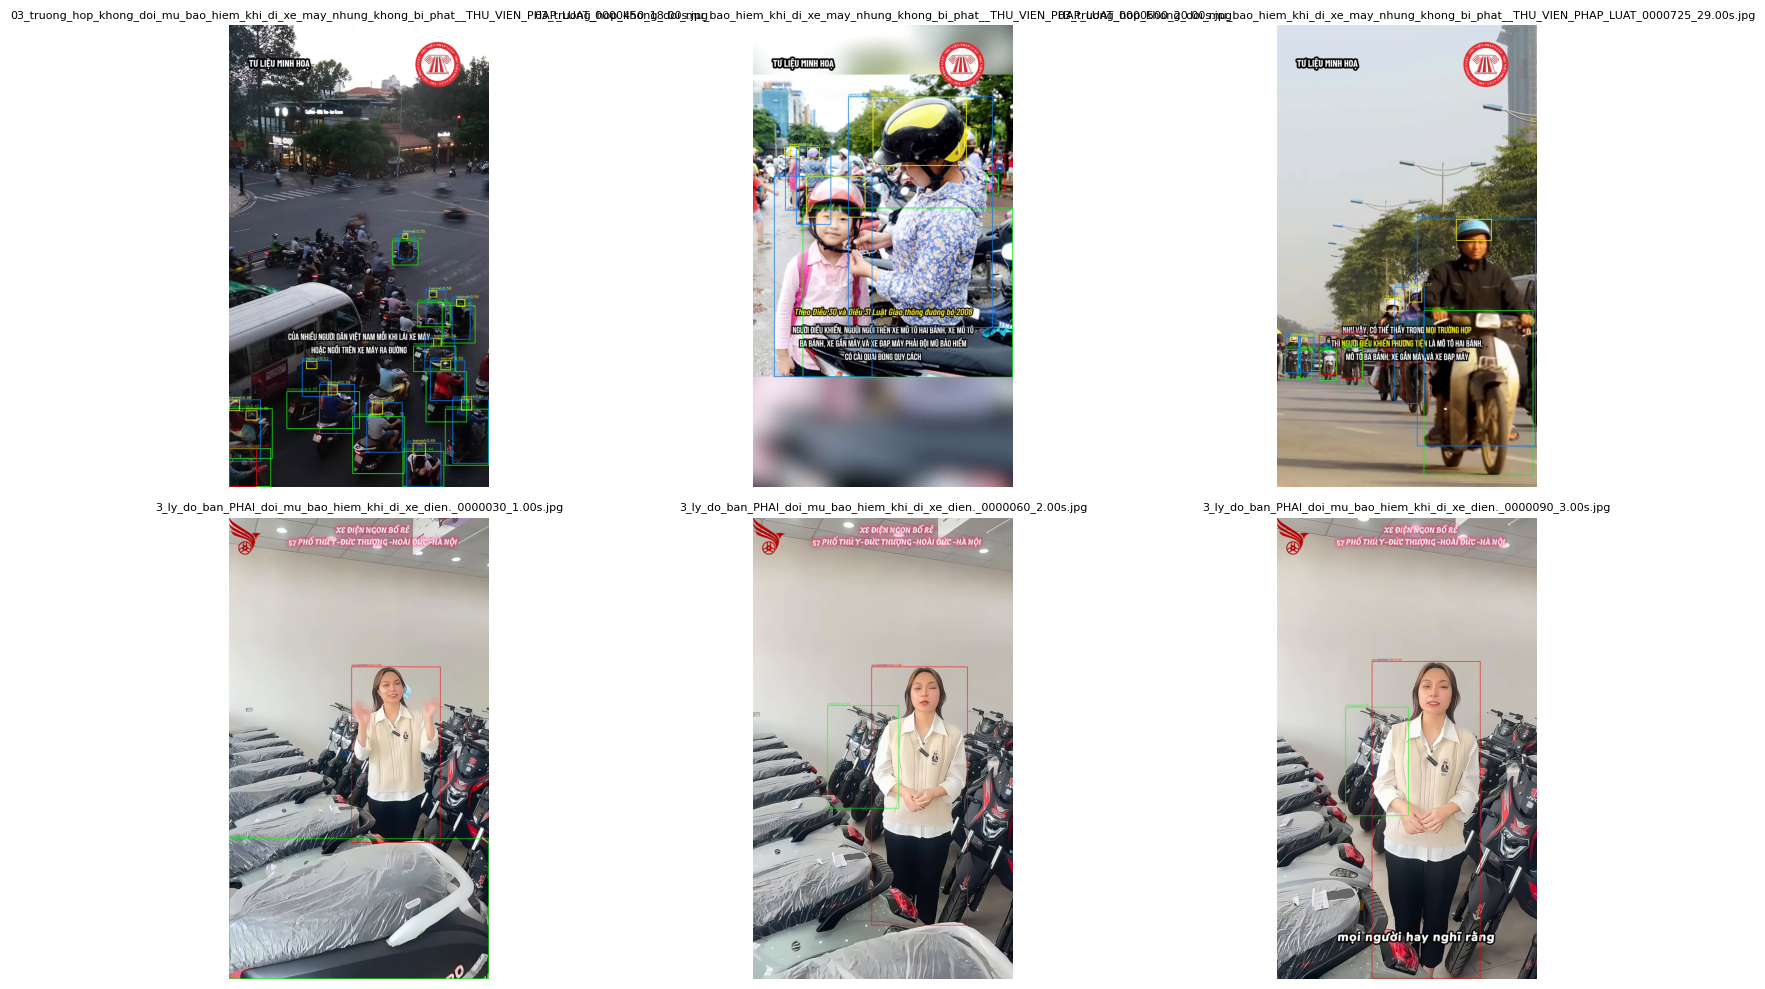

In [10]:
import matplotlib.pyplot as plt

debug_dir = Path(summary["output_root"]) / "debug"
debug_images = sorted(debug_dir.glob("*.jpg"))
print(f"Debug images: {len(debug_images)}")

if debug_images:
    sample = debug_images[:6]
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for ax, p in zip(axes, sample):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(p.name, fontsize=8)
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No debug images generated yet.")